#IMPORT LIBRARIES

In [16]:
import pandas as pd
import os
import sys
import os

#IMPORT WORKING DATAFRAME WITH PRE_APPLIED FILTERS

In [17]:
# add parent directory to the Python path
parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from working_df import  filtered_df 

working_df_ = filtered_df()

The connection to the DB has been successfully established ✅
Rows loaded: 1214532
Columns: ['index', 'hospital_name', 'hospital_address_single', 'zip4', 'setting', 'modifiers', 'standard_charge_gross', 'standard_charge_discounted_cash', 'payer_name', 'plan_name', 'standard_charge_negotiated_dollar', 'standard_charge_negotiated_percentage', 'standard_charge_min', 'standard_charge_max', 'bucket', 'specification', 'specification_plan', 'cpt_code', 'description', 'simple description', 'specialty', 'category', 'rate_using_min', 'rate_using_max', 'county']


In [18]:
import pandas as pd

def remove_outliers_by_cpt(df):

    # Compute Q1, Q3 and IQR per CPT code
    q1 = df.groupby(["cpt_code","bucket"])["rate_using_max"].transform(lambda x: x.quantile(0.25))
    q3 = df.groupby(["cpt_code","bucket"])["rate_using_max"].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    # Calculate lower and upper bounds
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Filter out outliers
    df_clean = df[(df["rate_using_max"] >= lower) & (df["rate_using_max"] <= upper)]

    return df_clean

clean_df = remove_outliers_by_cpt(working_df_)


In [19]:

print("Rows after outlier removal:", len(clean_df))

Rows after outlier removal: 1111491


In [20]:
#LOAD QUALITY DATA
quality = pd.read_csv(parent_dir + '/quality scores/Hospital_General_Information.csv')

#PRE PROCESS QUALITY DATA

In [21]:
#only keep necessary columns, facility name and Hospital overall rating
quality = quality[['Facility Name', 'Hospital overall rating']]

#drop Hospitals overall rating that are Not Available
quality = quality[quality['Hospital overall rating'].notnull() & (quality['Hospital overall rating'] != 'Not Available')]

#GROUP BY FACILITY NAME AND TAKE THE MEAN OF THE RATINGS ROUNDED UP TO THE NEAREST INTEGER
quality['Hospital overall rating'] = quality['Hospital overall rating'].astype(int)
quality = quality.groupby('Facility Name')['Hospital overall rating'].mean().round().astype(int).reset_index()



In [22]:
merge_df = pd.merge(clean_df, quality, left_on='hospital_name', right_on='Facility Name', how='inner')

merge_df = merge_df.drop(columns=['Facility Name'])
print("Rows after merging with quality data:", len(merge_df))


Rows after merging with quality data: 720205


In [23]:
#drop rows where specialty in Neurology or Pediatric Surgery, and setting is not inpatient
merge_df = merge_df[~merge_df['specialty'].isin(['Neurology', 'Pediatric Surgery'])]
merge_df = merge_df[merge_df['setting'] != 'inpatient']

In [24]:
#show distinct count of hospital_address_single, zip4, cpt_code
print("Distinct hospital addresses:", merge_df['hospital_address_single'].nunique())
print("Distinct ZIP4 codes:", merge_df['zip4'].nunique())
print("Distinct CPT codes:", merge_df['cpt_code'].nunique())

Distinct hospital addresses: 81
Distinct ZIP4 codes: 59
Distinct CPT codes: 98


In [25]:
display(merge_df.head())
display(merge_df.columns.tolist())

,index,hospital_name,hospital_address_single,zip4,setting,modifiers,standard_charge_gross,standard_charge_discounted_cash,payer_name,plan_name,...,specification_plan,cpt_code,description,simple description,specialty,category,rate_using_min,rate_using_max,county,Hospital overall rating
0,9632908,HCA FLORIDA BRANDON HOSPITAL,"8951 CYPRESS MANOR DR, TAMPA, FL, 33647",33647,outpatient,None,NaN,NaN,cigna,ppo,...,Other Commercial,52204,"Cystourethroscopy, with biopsy.",Bladder biopsy,Urology,Surgery (Urinary System),10268.0000,10268.00000,Hillsborough,2
1,9603849,HCA FLORIDA BRANDON HOSPITAL,"8951 CYPRESS MANOR DR, TAMPA, FL, 33647",33647,outpatient,None,NaN,NaN,aetna,gatedcomm,...,Other Commercial,97164,Physical therapy re-evaluation of established ...,Physical therapy re-evaluation of established ...,Physical Medicine & Rehabilitation,Evaluation,15.6604,23.41206,Hillsborough,2
2,9604352,HCA FLORIDA BRANDON HOSPITAL,"12530 US HIGHWAY 301 S, RIVERVIEW, FL, 33578",33578,outpatient,None,NaN,NaN,aetna,qhp,...,QHP,97116,Gait training (including stair climbing) to im...,"Gait training, 15 min.",Physical Medicine & Rehabilitation,Therapeutic Procedure,4.6710,7.17604,Hillsborough,2
3,9604354,HCA FLORIDA BRANDON HOSPITAL,"8951 CYPRESS MANOR DR, TAMPA, FL, 33647",33647,outpatient,None,NaN,NaN,aetna,qhp,...,QHP,97116,Gait training (including stair climbing) to im...,"Gait training, 15 min.",Physical Medicine & Rehabilitation,Therapeutic Procedure,4.6710,7.17604,Hillsborough,2
4,9612367,HCA FLORIDA BRANDON HOSPITAL,"119 OAKFIELD DRIVE, BRANDON, FL, 33511",33511,outpatient,GP|CQ,NaN,NaN,bcbs,mcrppo,...,Medicare,97116,Gait training (including stair climbing) to im...,"Gait training, 15 min.",Physical Medicine & Rehabilitation,Therapeutic Procedure,24.8100,24.81000,Hillsborough,2


['index',
 'hospital_name',
 'hospital_address_single',
 'zip4',
 'setting',
 'modifiers',
 'standard_charge_gross',
 'standard_charge_discounted_cash',
 'payer_name',
 'plan_name',
 'standard_charge_negotiated_dollar',
 'standard_charge_negotiated_percentage',
 'standard_charge_min',
 'standard_charge_max',
 'bucket',
 'specification',
 'specification_plan',
 'cpt_code',
 'description',
 'simple description',
 'specialty',
 'category',
 'rate_using_min',
 'rate_using_max',
 'county',
 'Hospital overall rating']

In [26]:
from cpt_rating import build_cpt_rating_summary

In [27]:
from cpt_rating import build_cpt_rating_summary

cpt_rating_summary = build_cpt_rating_summary(merge_df)

print("CPT Rating Summary:")
display(cpt_rating_summary.head())

CPT Rating Summary:


,cpt_code,zip4,Hospital overall rating,Count of Negotiated Plans,Distinct Hospitals,Median Price Govt,Median Price Comm,Commercial vs Govt deviation median
0,10040,32205,3,52.0,1.0,2295.0,6110.118,166.236078
1,10040,32210,3,52.0,1.0,2295.0,6110.118,166.236078
2,10040,32216,2,96.0,1.0,2250.0,6015.000,167.333333
3,10040,32223,2,96.0,1.0,2250.0,6015.000,167.333333
4,10040,32225,2,96.0,1.0,2250.0,6015.000,167.333333


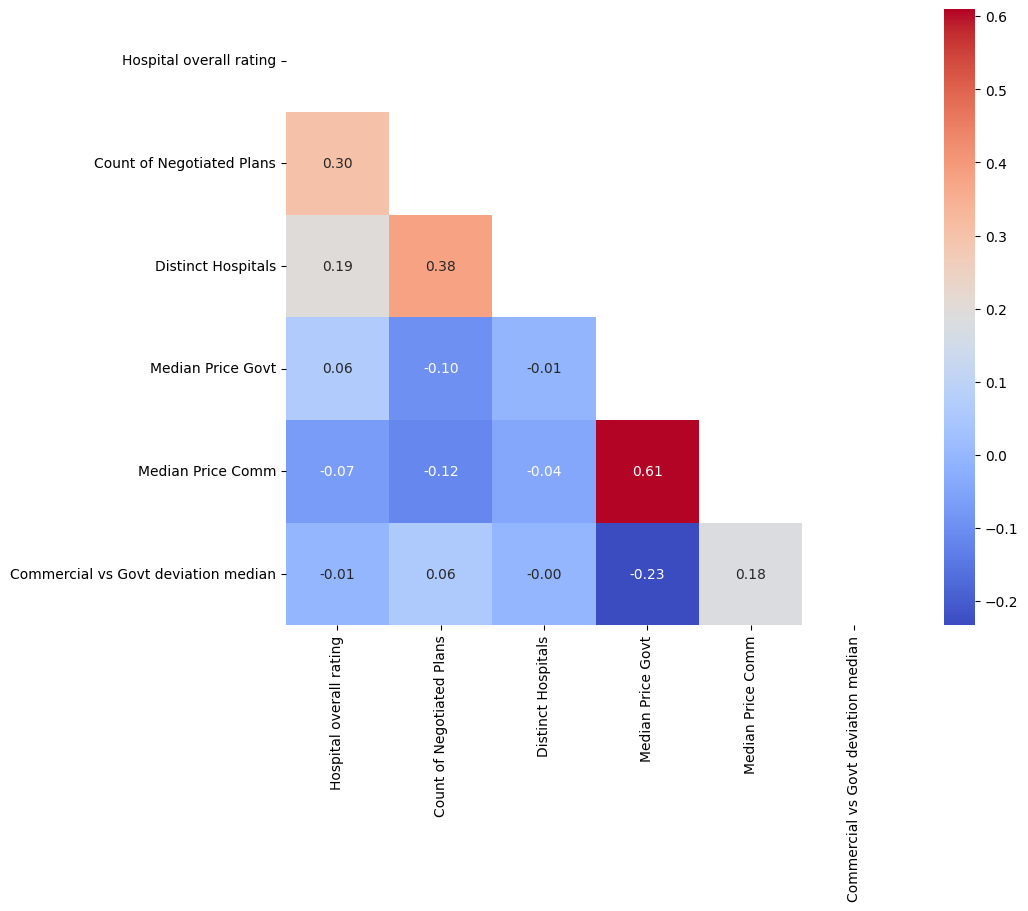

In [28]:
#show bottom half of correlation heatmap between numerical features in merge_df except for cpt_code and hospital_name
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


corr = cpt_rating_summary.select_dtypes(include=['number']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)
plt.show()

In [29]:
print(len(merge_df))
print(len(cpt_rating_summary))

690688
4895


In [31]:
display(merge_df)

,index,hospital_name,hospital_address_single,zip4,setting,modifiers,standard_charge_gross,standard_charge_discounted_cash,payer_name,plan_name,...,specification_plan,cpt_code,description,simple description,specialty,category,rate_using_min,rate_using_max,county,Hospital overall rating
0,9632908,HCA FLORIDA BRANDON HOSPITAL,"8951 CYPRESS MANOR DR, TAMPA, FL, 33647",33647,outpatient,None,NaN,NaN,cigna,ppo,...,Other Commercial,52204,"Cystourethroscopy, with biopsy.",Bladder biopsy,Urology,Surgery (Urinary System),10268.0000,10268.00000,Hillsborough,2
1,9603849,HCA FLORIDA BRANDON HOSPITAL,"8951 CYPRESS MANOR DR, TAMPA, FL, 33647",33647,outpatient,None,NaN,NaN,aetna,gatedcomm,...,Other Commercial,97164,Physical therapy re-evaluation of established ...,Physical therapy re-evaluation of established ...,Physical Medicine & Rehabilitation,Evaluation,15.6604,23.41206,Hillsborough,2
2,9604352,HCA FLORIDA BRANDON HOSPITAL,"12530 US HIGHWAY 301 S, RIVERVIEW, FL, 33578",33578,outpatient,None,NaN,NaN,aetna,qhp,...,QHP,97116,Gait training (including stair climbing) to im...,"Gait training, 15 min.",Physical Medicine & Rehabilitation,Therapeutic Procedure,4.6710,7.17604,Hillsborough,2
3,9604354,HCA FLORIDA BRANDON HOSPITAL,"8951 CYPRESS MANOR DR, TAMPA, FL, 33647",33647,outpatient,None,NaN,NaN,aetna,qhp,...,QHP,97116,Gait training (including stair climbing) to im...,"Gait training, 15 min.",Physical Medicine & Rehabilitation,Therapeutic Procedure,4.6710,7.17604,Hillsborough,2
4,9612367,HCA FLORIDA BRANDON HOSPITAL,"119 OAKFIELD DRIVE, BRANDON, FL, 33511",33511,outpatient,GP|CQ,NaN,NaN,bcbs,mcrppo,...,Medicare,97116,Gait training (including stair climbing) to im...,"Gait training, 15 min.",Physical Medicine & Rehabilitation,Therapeutic Procedure,24.8100,24.81000,Hillsborough,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720200,2850043,BAPTIST HOSPITAL OF MIAMI,"14661 SW 56 St, Miami,FL 33175",33175,both,None,14874.0,9668.1,MEDICARE,DEVOTED HEALTH MC HMO,...,Medicare,52332,"Cystourethroscopy, with insertion of indwellin...",Temporary tube placement with scope,Urology,Surgery (Urinary System),4425.6300,4425.63000,Miami-Dade,4
720201,2850044,BAPTIST HOSPITAL OF MIAMI,"11805 S. Dixie Hwy, Miami,FL 33156",33156,both,None,14874.0,9668.1,MEDICARE,DEVOTED HEALTH MC HMO,...,Medicare,52332,"Cystourethroscopy, with insertion of indwellin...",Temporary tube placement with scope,Urology,Surgery (Urinary System),4425.6300,4425.63000,Miami-Dade,4
720202,2850045,BAPTIST HOSPITAL OF MIAMI,"8950 SW 152 Street. Suite 103, Palmetto Bay,FL...",33157,both,None,14874.0,9668.1,MEDICARE,DEVOTED HEALTH MC HMO,...,Medicare,52332,"Cystourethroscopy, with insertion of indwellin...",Temporary tube placement with scope,Urology,Surgery (Urinary System),4425.6300,4425.63000,Miami-Dade,4
720203,2850046,BAPTIST HOSPITAL OF MIAMI,"1228 S Pine Island RD. STE 410, Plantation,FL ...",33324,both,None,14874.0,9668.1,MEDICARE,DEVOTED HEALTH MC HMO,...,Medicare,52332,"Cystourethroscopy, with insertion of indwellin...",Temporary tube placement with scope,Urology,Surgery (Urinary System),4425.6300,4425.63000,Broward,4


In [38]:
predict_df = merge_df.drop(columns=['index', 'hospital_name', 'hospital_address_single', 'county','standard_charge_negotiated_dollar','modifiers','standard_charge_max','standard_charge_min','description', 'specialty', 'setting','zip4','standard_charge_gross','standard_charge_discounted_cash','payer_name','plan_name','specification_plan','simple description','standard_charge_negotiated_percentage','specialty','category','rate_using_min'])

In [39]:
display(predict_df)

,bucket,specification,cpt_code,rate_using_max,Hospital overall rating
0,Commercial,Cigna,52204,10268.00000,2
1,Commercial,Aetna,97164,23.41206,2
2,Commercial,Aetna,97116,7.17604,2
3,Commercial,Aetna,97116,7.17604,2
4,Government,Medicare,97116,24.81000,2
...,...,...,...,...,...
720200,Government,Medicare,52332,4425.63000,4
720201,Government,Medicare,52332,4425.63000,4
720202,Government,Medicare,52332,4425.63000,4
720203,Government,Medicare,52332,4425.63000,4


In [43]:
#prepare predictive modeling separate target variable rate_using_max 
X= predict_df.drop(columns=["rate_using_max"])

# Step 2: Convert categorical columns into dummy variables
X = pd.get_dummies(X)  # Dummy encoding for categorical variables

# Convert all boolean columns in X to numeric (0 and 1)
X = X.applymap(lambda x: int(x) if isinstance(x, bool) else x)

# Convert all columns in X to numeric datatypes
X = X.apply(pd.to_numeric, errors='coerce')

y = predict_df["rate_using_max"]


C:\Users\gio12\AppData\Local\Temp\ipykernel_35744\1566199903.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: int(x) if isinstance(x, bool) else x)


In [44]:
#SPLIT DATA INTO TRAIN AND TEST SET
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# Build a Linear Regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [46]:
# Display model features and coefficients
features = X_train.columns
coefficients = model.coef_
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
display(coeff_df)

,Feature,Coefficient
0,Hospital overall rating,-1.428095e+02
1,bucket_Commercial,-2.072258e+12
2,bucket_Government,-2.072258e+12
3,specification_Aetna,-7.249555e+12
4,specification_Blue Cross Blue Shield,-7.249555e+12
...,...,...
102,cpt_code_99285,-2.232071e+12
103,cpt_code_99291,-2.232071e+12
104,cpt_code_99401,-2.232071e+12
105,cpt_code_99407,-2.232071e+12


In [47]:
# Step 6: Evaluate the model
y_pred = model.predict(X_test)
linear_r2 = r2_score(y_test, y_pred)
linear_mse = mean_squared_error(y_test, y_pred)
print("\nModel Performance:")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")



model_performance_df = pd.DataFrame({
    'Model Name':['Simple Linear Regression Training'],
    'R-squared': linear_r2,
    'MSE': linear_mse
})

display(model_performance_df)


Model Performance:
R-squared: 0.7453
MAE: 1532.1493
MSE: 8816898.4159


,Model Name,R-squared,MSE
0,Simple Linear Regression Training,0.745335,8.816898e+06


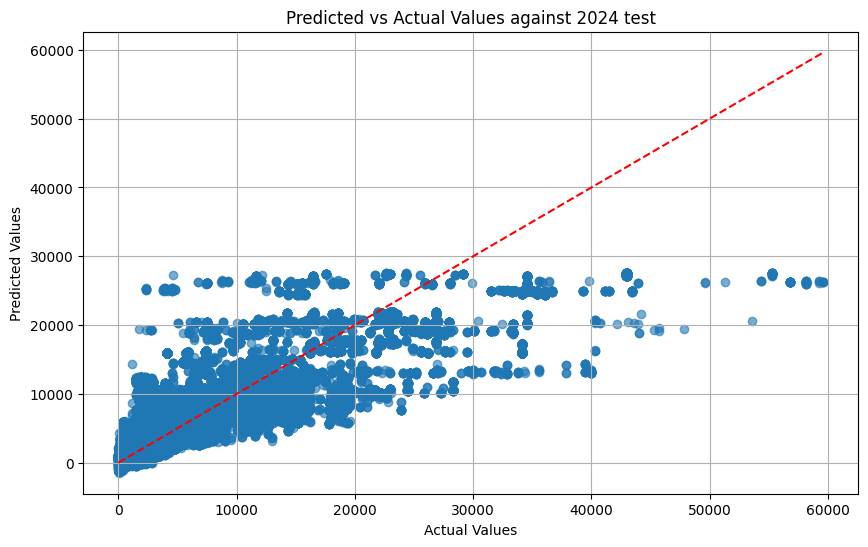

In [48]:
import matplotlib.pyplot as plt

# Step 7: Plot predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter((y_test), (y_pred), alpha=0.6)
plt.plot([min((y_test)), max((y_test))], [min((y_test)), max((y_test))], color='red', linestyle='--')
plt.title('Predicted vs Actual Values against 2024 test')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()
plt.show()

In [49]:
import statsmodels.api as sm

# Add a constant column for the intercept
X_with_const = sm.add_constant(X)

# Fit an OLS model
model_sm = sm.OLS(y, X_with_const).fit()

# Display summary for feature selection
print("\nFeature Selection Summary:")
print(model_sm.summary())


Feature Selection Summary:
                            OLS Regression Results                            
Dep. Variable:         rate_using_max   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                 1.866e+04
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:29:27   Log-Likelihood:            -6.5110e+06
No. Observations:              690688   AIC:                         1.302e+07
Df Residuals:                  690581   BIC:                         1.302e+07
Df Model:                         106                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [52]:
#AGAINST TRAINING_DATA

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions using the OLS model
predictions = model_sm.predict(X_with_const)


# Calculate MAE and MSE
mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)


# Calculate R-squared
r_squared = model_sm.rsquared



new_row = {'Model Name': 'OLS regression Training', 'R-squared': r_squared, 'MSE': mse}
# pandas.DataFrame.append is deprecated/removed; use concat to add a new row
model_performance_df = pd.concat([model_performance_df, pd.DataFrame([new_row])], ignore_index=True)

display(model_performance_df)

,Model Name,R-squared,MSE
0,Simple Linear Regression Training,0.745335,8.816898e+06
1,OLS regression Training,0.741209,9.028798e+06


In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import pandas as pd

# Initialize the RandomForestRegressor with oob_score enabled
rf = RandomForestRegressor(n_estimators=30,oob_score=True)
rf_model = rf.fit(X_train, y_train)




In [56]:
# Evaluate the model
predictions = rf_model.predict(X_test)
rmse = mean_squared_error(y_test, predictions, squared=False)


# Calculate R2 score on training dataset
r2 = r2_score(y_test, predictions)





c:\Users\gio12\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [58]:
print("\nRandom Forest Model Performance:")
print(f"R-squared: {r2:.4f}")
print(f"MSE: {rmse:.4f}")


Random Forest Model Performance:
R-squared: 0.8468
MSE: 2303.4110


In [ ]:

scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')


# Calculate OOB error
oob_error = 1 - rf_model.oob_score_

# # Display the results
# results_df = pd.DataFrame({
#     'Model': ['Random Forest'],
#     'RMSE': [rmse],
#     'R2': [r2],
#     # 'cross val': [scores],
#     'means': [scores.mean()],
#     'OOB Error': [oob_error]
# })

# display(results_df)

# # Display the results of test
# results_df_test = pd.DataFrame({
#     'Model': ['Random Forest'],
#     'RMSE': [rmse_test],
#     'R2': [r2_test],
#     # 'cross val': [test_scores],
#     'means': [test_scores.mean()],
#     'OOB Error': [oob_error]
# })



c:\Users\gio12\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\gio12\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


AttributeError: 'DataFrame' object has no attribute 'append'

In [60]:
new_row = {'Model Name': 'Random Forest Train', 'R-squared': r2, 'MSE': rmse}
# pandas.DataFrame.append is deprecated/removed in recent pandas versions — use pd.concat instead
model_performance_df = pd.concat([model_performance_df, pd.DataFrame([new_row])], ignore_index=True)

In [61]:
print(model_performance_df)

                          Model Name  R-squared           MSE
0  Simple Linear Regression Training   0.745335  8.816898e+06
1            OLS regression Training   0.741209  9.028798e+06
2                Random Forest Train   0.846751  2.303411e+03
